In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import dataloader
from torchvision import datasets, transforms
from torchvision.models import vit_b_16
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashwatwork/identifying-disease-in-tea-leafs")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'identifying-disease-in-tea-leafs' dataset.
Path to dataset files: /kaggle/input/identifying-disease-in-tea-leafs


In [ ]:
data_dir = os.path.join(path, 'tea sickness dataset')

# Define transformations for the images
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to 224x224 for ViT
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet normalization
])

# Load the dataset
full_dataset = datasets.ImageFolder(data_dir, transform=transform)

# Define the split ratios
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

# Calculate the number of samples for each split
dataset_size = len(full_dataset)
train_size = int(train_ratio * dataset_size)
val_size = int(val_ratio * dataset_size)
test_size = dataset_size - train_size - val_size # Ensure all samples are used

# Split the dataset
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size]
)

# Define batch size
batch_size = 32

# Create DataLoaders for each split
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of classes: {len(full_dataset.classes)}")
print(f"Class names: {full_dataset.classes}")

Train dataset size: 708
Validation dataset size: 88
Test dataset size: 89
Number of classes: 8
Class names: ['Anthracnose', 'algal leaf', 'bird eye spot', 'brown blight', 'gray light', 'healthy', 'red leaf spot', 'white spot']


### Displaying Sample Images from Each Dataset Split

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img, title=None):
    # Unnormalize image for display
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title is not None:
        plt.title(title)
    plt.axis('off') # Hide axes

# Helper function to unnormalize and display images
def unnormalize_and_show(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img_tensor.numpy().transpose((1, 2, 0))  # Convert from C, H, W to H, W, C
    img_np = std * img_np + mean  # Unnormalize
    img_np = np.clip(img_np, 0, 1) # Clip values to [0, 1]
    return img_np

#### Training Dataset Samples

Labels: tensor([0, 0, 5, 4, 0, 1, 6, 3, 6, 0, 4, 5, 2, 5, 1, 1, 0, 2, 7, 2, 2, 5, 7, 7,
        5, 7, 1, 4, 4, 2, 6, 4])
Class names: ['Anthracnose', 'Anthracnose', 'healthy', 'gray light', 'Anthracnose', 'algal leaf', 'red leaf spot', 'brown blight', 'red leaf spot', 'Anthracnose', 'gray light', 'healthy', 'bird eye spot', 'healthy', 'algal leaf', 'algal leaf', 'Anthracnose', 'bird eye spot', 'white spot', 'bird eye spot', 'bird eye spot', 'healthy', 'white spot', 'white spot', 'healthy', 'white spot', 'algal leaf', 'gray light', 'gray light', 'bird eye spot', 'red leaf spot', 'gray light']


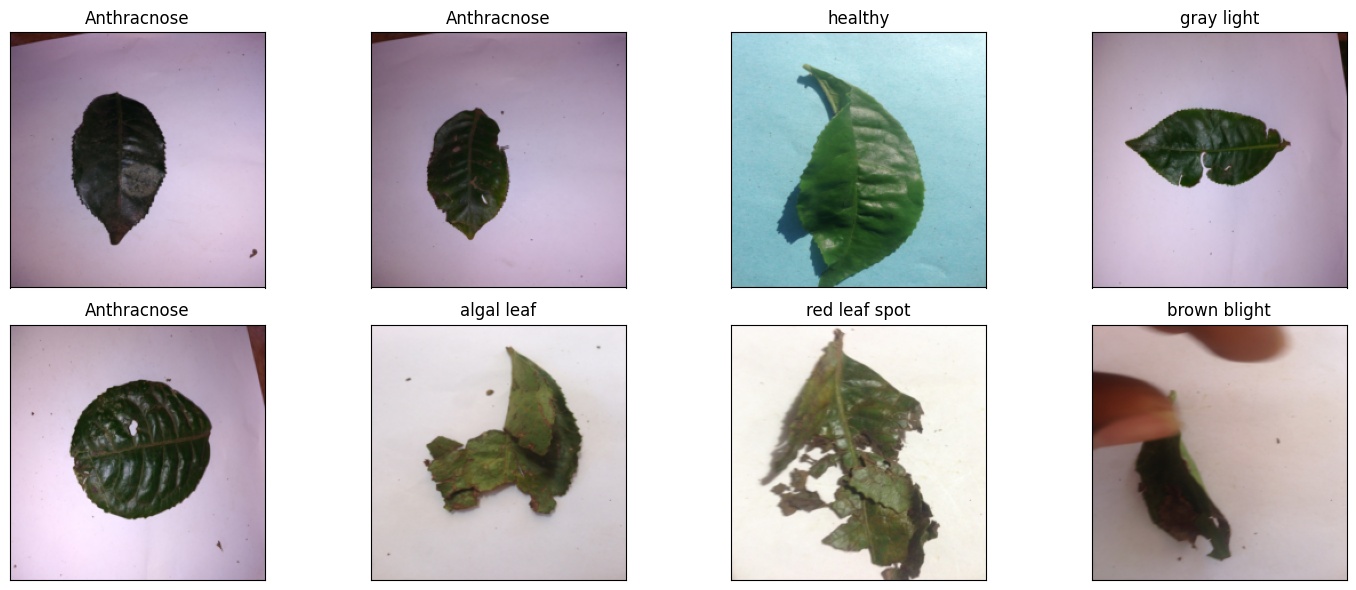

In [ ]:

images, labels = next(iter(train_loader))

# Print the labels and corresponding class names
print('Labels:', labels)
print('Class names:', [full_dataset.classes[label] for label in labels])

# Show images
fig = plt.figure(figsize=(15, 6))
for i in range(min(len(images), 8)): # Display up to 8 images
    ax = fig.add_subplot(2, 4, i + 1, xticks=[], yticks=[])
    plt.imshow(unnormalize_and_show(images[i]))
    ax.set_title(full_dataset.classes[labels[i]])
plt.tight_layout()
plt.show()

#### Validation Dataset Samples

Labels: tensor([3, 0, 3, 0, 0, 3, 7, 2, 1, 0, 4, 5, 7, 6, 2, 1, 4, 1, 2, 6, 3, 6, 5, 4,
        3, 0, 6, 1, 4, 5, 4, 1])
Class names: ['brown blight', 'Anthracnose', 'brown blight', 'Anthracnose', 'Anthracnose', 'brown blight', 'white spot', 'bird eye spot', 'algal leaf', 'Anthracnose', 'gray light', 'healthy', 'white spot', 'red leaf spot', 'bird eye spot', 'algal leaf', 'gray light', 'algal leaf', 'bird eye spot', 'red leaf spot', 'brown blight', 'red leaf spot', 'healthy', 'gray light', 'brown blight', 'Anthracnose', 'red leaf spot', 'algal leaf', 'gray light', 'healthy', 'gray light', 'algal leaf']


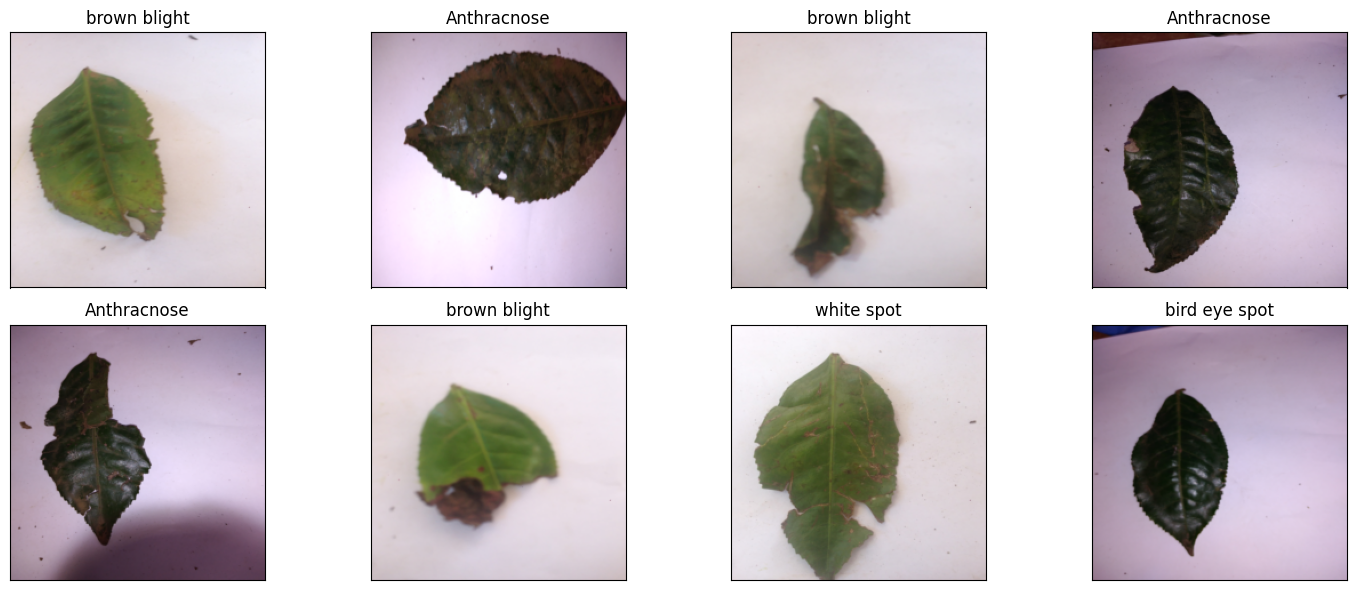

In [ ]:

images, labels = next(iter(val_loader))

# Print the labels and corresponding class names
print('Labels:', labels)
print('Class names:', [full_dataset.classes[label] for label in labels])

# Show images
fig = plt.figure(figsize=(15, 6))
for i in range(min(len(images), 8)): # Display up to 8 images
    ax = fig.add_subplot(2, 4, i + 1, xticks=[], yticks=[])
    plt.imshow(unnormalize_and_show(images[i]))
    ax.set_title(full_dataset.classes[labels[i]])
plt.tight_layout()
plt.show()

#### Test Dataset Samples

Labels: tensor([7, 0, 3, 6, 6, 1, 4, 1, 0, 3, 7, 7, 4, 7, 6, 1, 6, 1, 3, 2, 0, 2, 6, 3,
        0, 6, 2, 2, 7, 3, 6, 2])
Class names: ['white spot', 'Anthracnose', 'brown blight', 'red leaf spot', 'red leaf spot', 'algal leaf', 'gray light', 'algal leaf', 'Anthracnose', 'brown blight', 'white spot', 'white spot', 'gray light', 'white spot', 'red leaf spot', 'algal leaf', 'red leaf spot', 'algal leaf', 'brown blight', 'bird eye spot', 'Anthracnose', 'bird eye spot', 'red leaf spot', 'brown blight', 'Anthracnose', 'red leaf spot', 'bird eye spot', 'bird eye spot', 'white spot', 'brown blight', 'red leaf spot', 'bird eye spot']


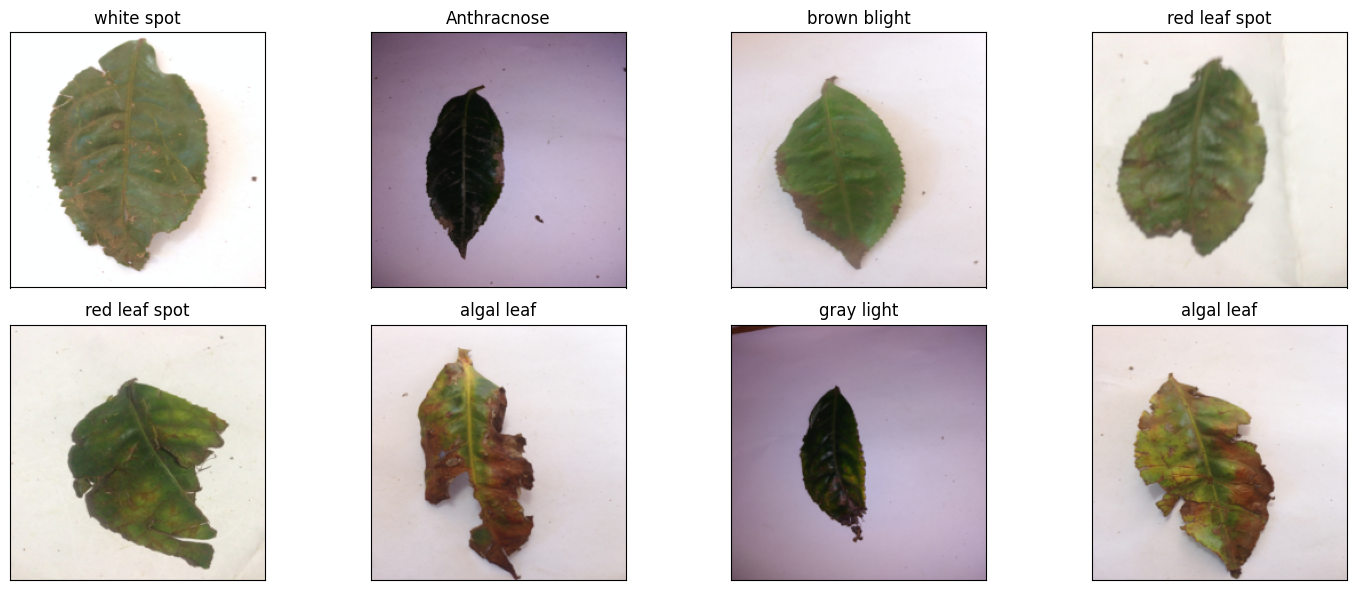

In [ ]:

images, labels = next(iter(test_loader))

# Print the labels and corresponding class names
print('Labels:', labels)
print('Class names:', [full_dataset.classes[label] for label in labels])

# Show images
fig = plt.figure(figsize=(15, 6))
for i in range(min(len(images), 8)): # Display up to 8 images
    ax = fig.add_subplot(2, 4, i + 1, xticks=[], yticks=[])
    plt.imshow(unnormalize_and_show(images[i]))
    ax.set_title(full_dataset.classes[labels[i]])
plt.tight_layout()
plt.show()

### Training and Evaluation Functions


In [ ]:
## Function to train the model for one epoch
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train() ## Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() ## Zero the parameter gradients

        outputs = model(inputs) ## Forward pass
        loss = criterion(outputs, labels) ## Calculate loss
        loss.backward() ## Backward pass
        optimizer.step() ## Optimize weights

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

## Function to evaluate the model
def evaluate_model(model, dataloader, criterion, device):
    model.eval() ## Set model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad(): ## Disable gradient calculation during evaluation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

### Model Fusion: ViT-B/16 + ResNet50

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import vit_b_16, resnet50, ViT_B_16_Weights, ResNet50_Weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ViTResNetFusionModel(nn.Module):
    def __init__(self, num_classes):
        super(ViTResNetFusionModel, self).__init__()

        # 1. Load pretrained ViT-B/16 and extract its feature size
        self.vit = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
        vit_feature_dim = self.vit.heads.head.in_features
        # Remove the classification head of ViT to get representation features
        self.vit.heads = nn.Identity()

        # 2. Load pretrained ResNet50 and extract its feature size
        self.resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
        resnet_feature_dim = self.resnet.fc.in_features
        # Remove the final fully connected layer of ResNet
        self.resnet.fc = nn.Identity()

        # Total concatenated feature dimension
        fusion_dim = vit_feature_dim + resnet_feature_dim

        # 3. Define a joint classification head
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extract features from both models
        vit_feats = self.vit(x)
        resnet_feats = self.resnet(x)

        # Concatenate features along the channel/feature dimension
        fused_feats = torch.cat((vit_feats, resnet_feats), dim=1)

        # Classify using the fused representation
        out = self.classifier(fused_feats)
        return out

# Initialize the fusion model
num_classes = len(full_dataset.classes)
fusion_model = ViTResNetFusionModel(num_classes=num_classes).to(device)
print("ViT-ResNet Fusion Model successfully initialized.")

ViT-ResNet Fusion Model successfully initialized.


### Training and Evaluating the Fusion Model

In [ ]:
criterion_fusion = nn.CrossEntropyLoss()
optimizer_fusion = optim.Adam(fusion_model.parameters(), lr=1e-5) # Using a slightly lower learning rate for joint fine-tuning

num_epochs_fusion = 10
best_fusion_val_acc = 0.0

train_losses_f = []
val_losses_f = []

for epoch in range(num_epochs_fusion):
    train_loss, train_acc = train_epoch(fusion_model, train_loader, criterion_fusion, optimizer_fusion, device)
    val_loss, val_acc = evaluate_model(fusion_model, val_loader, criterion_fusion, device)

    train_losses_f.append(train_loss)
    val_losses_f.append(val_loss)

    print(f'Epoch {epoch+1}/{num_epochs_fusion}:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    if val_acc > best_fusion_val_acc:
        best_fusion_val_acc = val_acc
        torch.save(fusion_model.state_dict(), 'best_fusion_model.pth')
        print('  -- Saved Best Fusion Model --')

# Load the best model and evaluate on the test set
fusion_model.load_state_dict(torch.load('best_fusion_model.pth'))
test_loss_f, test_acc_f = evaluate_model(fusion_model, test_loader, criterion_fusion, device)
print(f'\nFusion Model Final Test Loss: {test_loss_f:.4f}, Test Accuracy: {test_acc_f:.4f}')

Epoch 1/10:
  Train Loss: 1.9367, Train Acc: 0.3941
  Val Loss: 1.7427, Val Acc: 0.6364
  -- Saved Best Fusion Model --
Epoch 2/10:
  Train Loss: 1.5625, Train Acc: 0.7345
  Val Loss: 1.3462, Val Acc: 0.7614
  -- Saved Best Fusion Model --
Epoch 3/10:
  Train Loss: 1.1922, Train Acc: 0.7994
  Val Loss: 1.0499, Val Acc: 0.8182
  -- Saved Best Fusion Model --
Epoch 4/10:
  Train Loss: 0.9202, Train Acc: 0.8814
  Val Loss: 0.8166, Val Acc: 0.9091
  -- Saved Best Fusion Model --
Epoch 5/10:
  Train Loss: 0.6724, Train Acc: 0.9350
  Val Loss: 0.6356, Val Acc: 0.9318
  -- Saved Best Fusion Model --
Epoch 6/10:
  Train Loss: 0.4793, Train Acc: 0.9661
  Val Loss: 0.4584, Val Acc: 0.9659
  -- Saved Best Fusion Model --
Epoch 7/10:
  Train Loss: 0.3320, Train Acc: 0.9788
  Val Loss: 0.3461, Val Acc: 0.9545
Epoch 8/10:
  Train Loss: 0.2334, Train Acc: 0.9887
  Val Loss: 0.3034, Val Acc: 0.9432
Epoch 9/10:
  Train Loss: 0.1696, Train Acc: 0.9929
  Val Loss: 0.2416, Val Acc: 0.9659
Epoch 10/10:
  T

### Fusion Model Performance Visualization

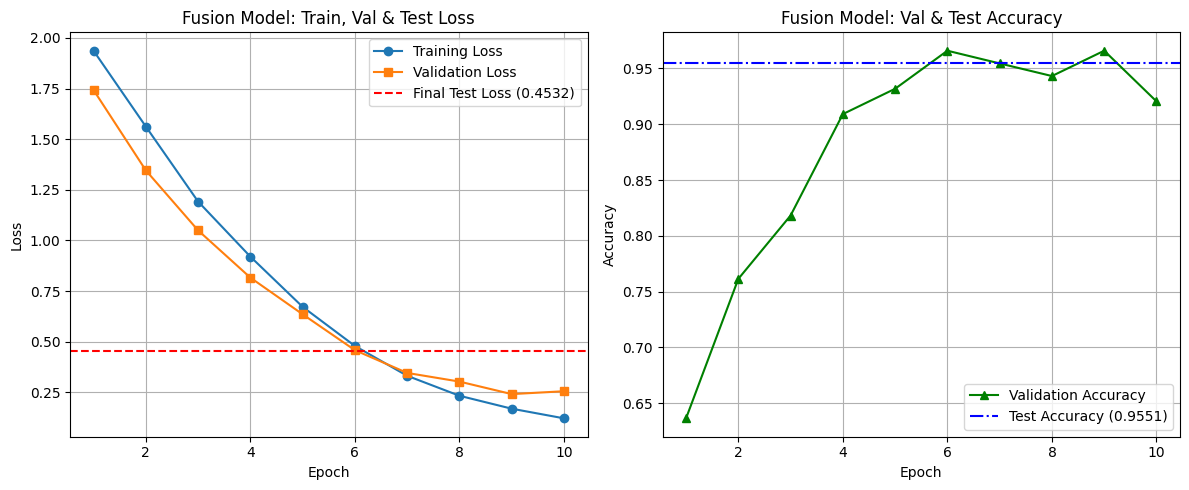

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))

# 1. Plot Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs_fusion + 1), train_losses_f, label='Training Loss', marker='o')
plt.plot(range(1, num_epochs_fusion + 1), val_losses_f, label='Validation Loss', marker='s')
plt.axhline(y=test_loss_f, color='r', linestyle='--', label=f'Final Test Loss ({test_loss_f:.4f})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fusion Model: Train, Val & Test Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
val_acc_progress = [0.6364, 0.7614, 0.8182, 0.9091, 0.9318, 0.9659, 0.9545, 0.9432, 0.9659, 0.9205]
plt.plot(range(1, num_epochs_fusion + 1), val_acc_progress, label='Validation Accuracy', color='green', marker='^')
plt.axhline(y=test_acc_f, color='blue', linestyle='-.', label=f'Test Accuracy ({test_acc_f:.4f})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Fusion Model: Val & Test Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Evaluating Predictions on Test Images

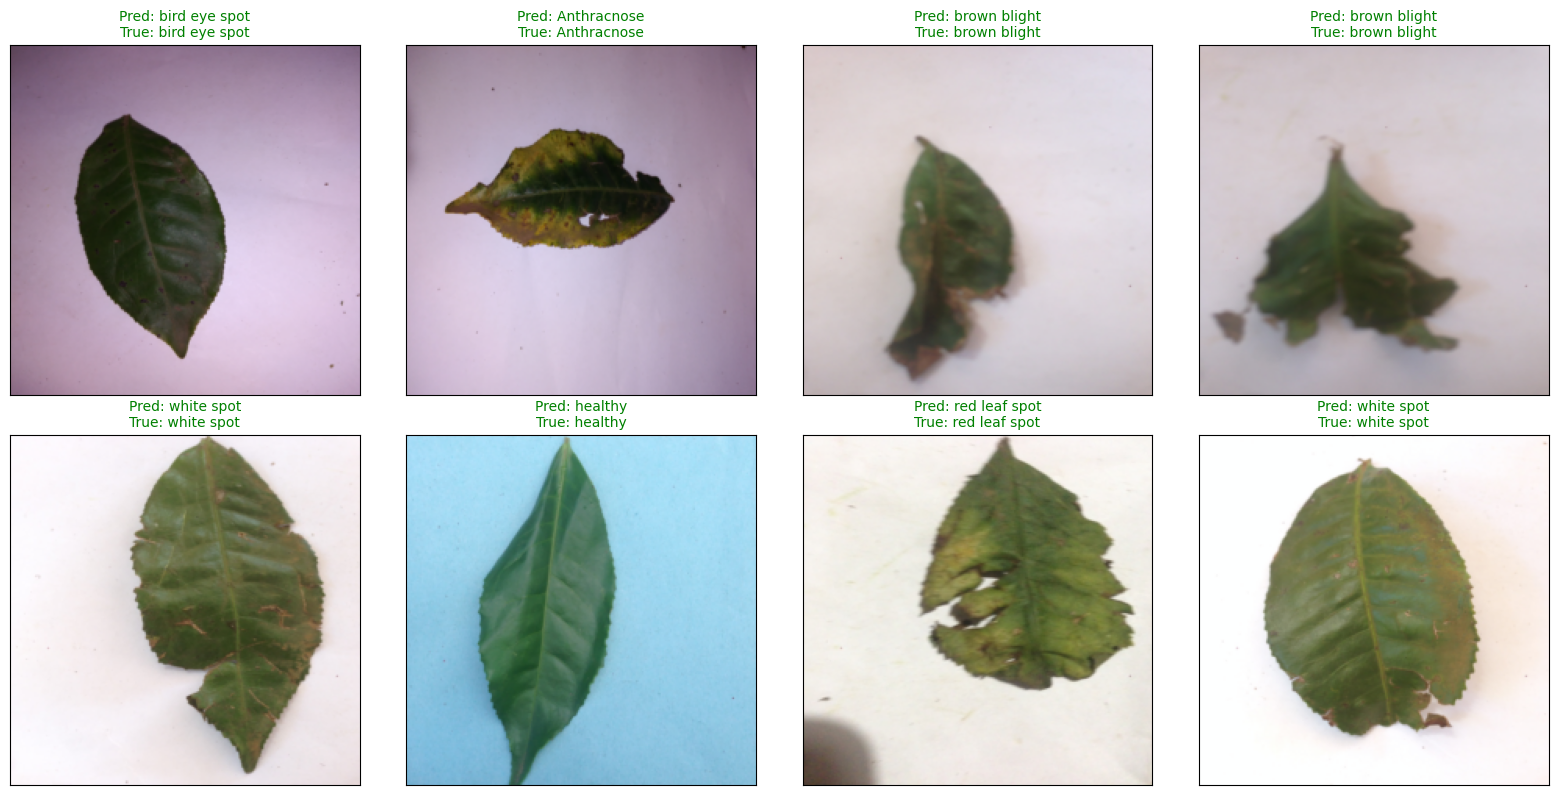

In [ ]:
import torch

# Ensure the fusion model is in evaluation mode
fusion_model.eval()

# Get a batch of images and labels from the test loader
test_images, test_labels = next(iter(test_loader))
test_images_dev, test_labels_dev = test_images.to(device), test_labels.to(device)

# Get predictions from the model
with torch.no_grad():
    outputs = fusion_model(test_images_dev)
    _, preds = torch.max(outputs, 1)

# Move tensors back to CPU for visualization
preds = preds.cpu().numpy()
test_labels = test_labels.numpy()

# Plot the first 8 test images with their predicted and true labels
fig = plt.figure(figsize=(16, 8))
for i in range(min(len(test_images), 8)):
    ax = fig.add_subplot(2, 4, i + 1, xticks=[], yticks=[])

    # Unnormalize and show the image
    plt.imshow(unnormalize_and_show(test_images[i]))

    pred_class = full_dataset.classes[preds[i]]
    true_class = full_dataset.classes[test_labels[i]]

    # Color green if correct, red if incorrect
    title_color = 'green' if preds[i] == test_labels[i] else 'red'

    ax.set_title(f"Pred: {pred_class}\nTrue: {true_class}", color=title_color, fontsize=10)

plt.tight_layout()
plt.show()